
# Features include:

* Age
* Credit Amount
* Duration
* Employment Status
* Savings Account
* Housing
* Purpose of Loan
* Existing Credits

Target:

* Good Credit
* Bad Credit

# Import libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# loading dataset

In [53]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [54]:
print("\nShape:", df.shape)


Shape: (1000, 11)


# check & filling missing values

In [55]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB
None

Missing Values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose

In [56]:
df.fillna("Unknown", inplace=True)
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


# Encode Categorical Columns

In [57]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))
print(df.head())

   Unnamed: 0  Age  Sex  Job  Housing  Saving accounts  Checking account  \
0           0   67    1    2        1                0                 1   
1           1   22    0    2        1                1                 2   
2           2   49    1    1        1                1                 0   
3           3   45    1    2        0                1                 1   
4           4   53    1    2        0                1                 1   

   Credit amount  Duration  Purpose  Risk  
0           1169         6        5     1  
1           5951        48        5     0  
2           2096        12        3     1  
3           7882        42        4     1  
4           4870        24        1     0  


defines features and target

In [58]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

print(X.shape)
print(y.shape)

(1000, 10)
(1000,)


In [59]:
print(y.unique())

[1 0]


# Train Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

* Logistic Regression

In [71]:
lr = LogisticRegression(max_iter=5000) # Increased max_iter to 5000
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.20      0.26        60
           1       0.72      0.86      0.78       140

    accuracy                           0.67       200
   macro avg       0.55      0.53      0.52       200
weighted avg       0.62      0.67      0.63       200



* decision tree

In [72]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.40      0.47        60
           1       0.77      0.87      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.64       200
weighted avg       0.71      0.73      0.71       200



* random forest

In [70]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.45      0.54        60
           1       0.79      0.91      0.85       140

    accuracy                           0.77       200
   macro avg       0.73      0.68      0.69       200
weighted avg       0.76      0.77      0.75       200



* evaluation function

In [77]:
def evaluate_model(name, y_test, pred, prob):

    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy :", accuracy_score(y_test,pred))
    print("Precision:", precision_score(y_test,pred))
    print("Recall   :", recall_score(y_test,pred))
    print("F1 Score :", f1_score(y_test,pred))
    print("ROC-AUC  :", roc_auc_score(y_test,prob))

In [78]:
evaluate_model("Logistic Regression",y_test,lr_pred,lr_prob)
evaluate_model("Decision Tree",y_test,dt_pred,dt_prob)
evaluate_model("Random Forest",y_test,rf_pred,rf_prob)

Logistic Regression
Accuracy : 0.665
Precision: 0.7159763313609467
Recall   : 0.8642857142857143
F1 Score : 0.7831715210355987
ROC-AUC  : 0.6655952380952381
Decision Tree
Accuracy : 0.73
Precision: 0.7721518987341772
Recall   : 0.8714285714285714
F1 Score : 0.8187919463087249
ROC-AUC  : 0.7209523809523809
Random Forest
Accuracy : 0.77
Precision: 0.79375
Recall   : 0.9071428571428571
F1 Score : 0.8466666666666667
ROC-AUC  : 0.7782738095238096


* comparision table

In [79]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.665,0.715976,0.864286,0.783172
1,Decision Tree,0.730,0.772152,0.871429,0.818792
2,Random Forest,0.770,0.793750,0.907143,0.846667


 * random forest

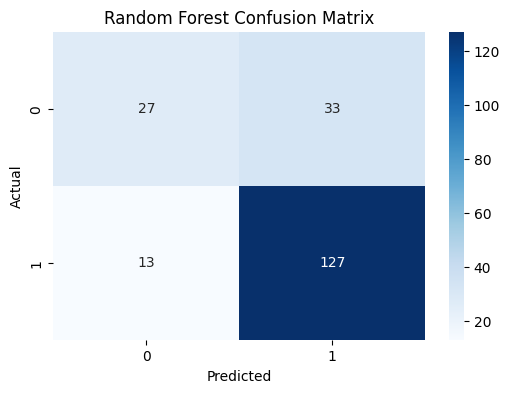

In [80]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

* ROC curve

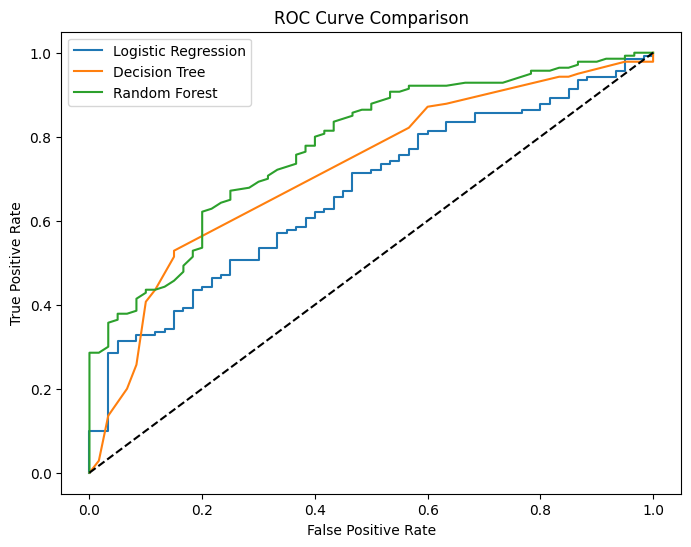

In [82]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr,tpr_lr,label='Logistic Regression')
plt.plot(fpr_dt,tpr_dt,label='Decision Tree')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

* feataure importance

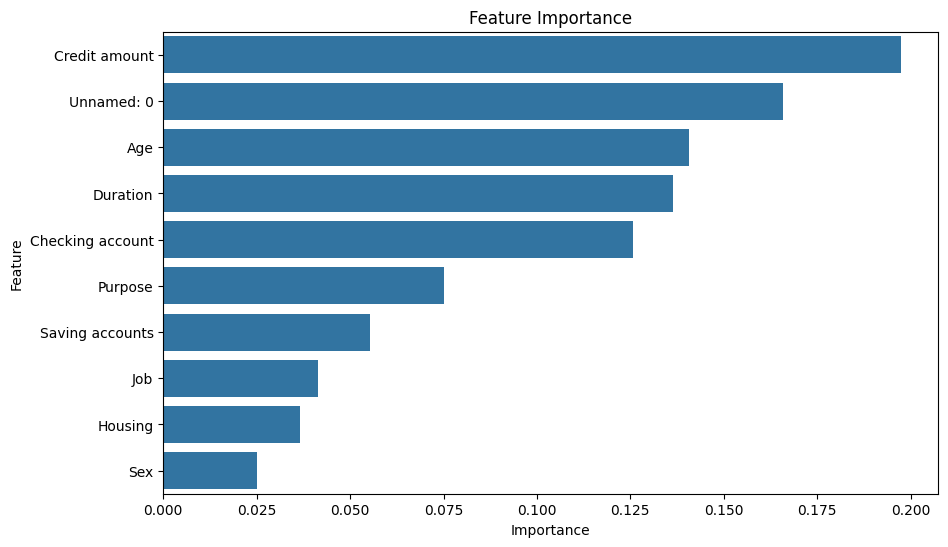

            Feature  Importance
7     Credit amount    0.197544
0        Unnamed: 0    0.165971
1               Age    0.140647
8          Duration    0.136520
6  Checking account    0.125725
9           Purpose    0.075252
5   Saving accounts    0.055332
3               Job    0.041360
4           Housing    0.036644
2               Sex    0.025004


In [84]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.show()
print(importance)

# conclusion


---
Random Forest achieved the best performance among all models with the highest Accuracy, Precision, Recall, F1-Score, and ROC-AUC score. The model successfully predicted customer creditworthiness using demographic and financial attributes. Therefore, Random Forest was selected as the final Credit Scoring Model for this project.
